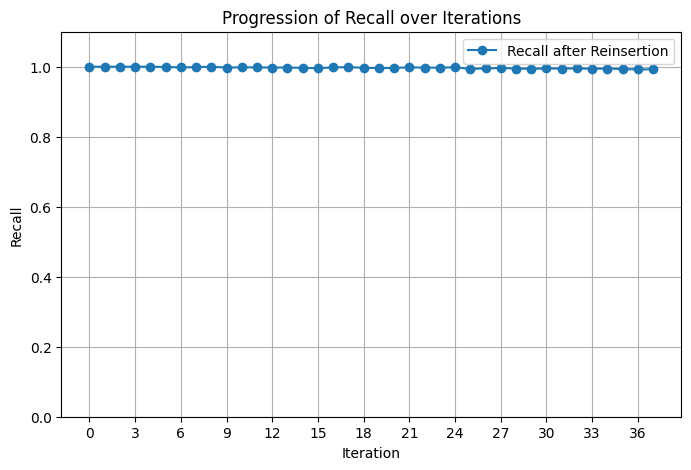

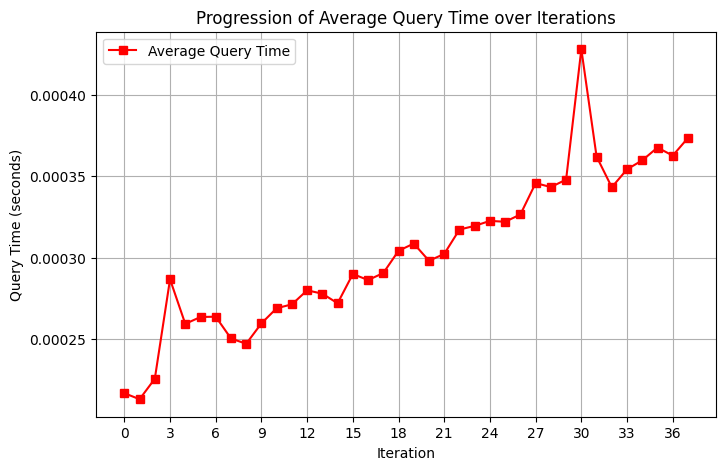

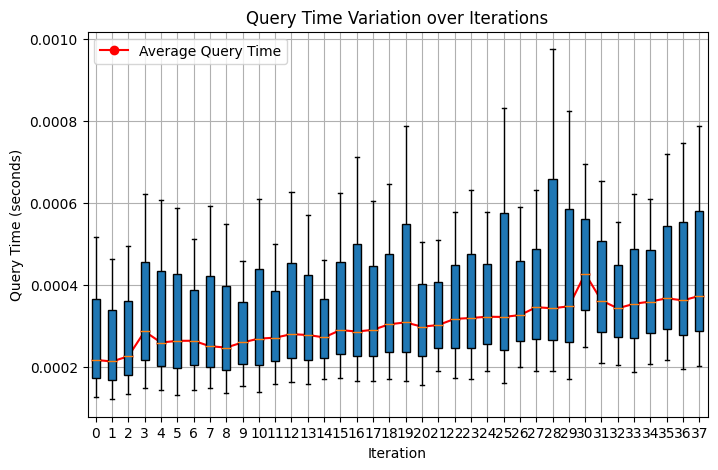

In [2]:
import json
import matplotlib.pyplot as plt
import numpy as np

# Load data from JSON file
def load_data_from_json(file_path):
    with open(file_path, "r") as file:
        return json.load(file)

# Plot recall and query time variation
def plot_recall_and_query_time_variation(file_path):
    data = load_data_from_json(file_path)
    
    iterations = [entry["iteration"] for entry in data]
    recalls = [entry["recall_after_reinsertion"] for entry in data]
    avg_query_times = [entry["average_query_time"] for entry in data]
    min_query_times = [entry["min_query_time"] for entry in data]
    max_query_times = [entry["max_query_time"] for entry in data]


    # Prepare data for boxplot
    query_time_variation = [ 
        [min_t, avg_t, max_t] for min_t, avg_t, max_t in zip(min_query_times, avg_query_times, max_query_times)
    ]

    # 1️⃣ Plot Recall Progression
    plt.figure(figsize=(8, 5))
    plt.plot(iterations, recalls, marker='o', linestyle='-', label="Recall after Reinsertion")
    plt.xlabel("Iteration")
    plt.ylabel("Recall")
    plt.title("Progression of Recall over Iterations")
    plt.ylim(0, 1.1)  # Adjust y-axis limits from 0 to 1.1
    step = max(1, len(iterations) // 10)  # Show around 10 ticks
    plt.xticks(np.arange(min(iterations), max(iterations) + 1, step))
    plt.grid(True)
    plt.legend()
    plt.show()

    # 2️⃣ Plot Average Query Time Progression
    plt.figure(figsize=(8, 5))
    plt.plot(iterations, avg_query_times, marker='s', linestyle='-', color='red', label="Average Query Time")
    plt.xlabel("Iteration")
    plt.ylabel("Query Time (seconds)")
    plt.title("Progression of Average Query Time over Iterations")
    step = max(1, len(iterations) // 10)  # Show around 10 ticks
    plt.xticks(np.arange(min(iterations), max(iterations) + 1, step))
    plt.grid(True)
    plt.legend()
    plt.show()

    # 3️⃣ Plot Query Time Variation (Min-Max Range)

    # Create a boxplot to show distribution of min, max, and avg query times
    plt.figure(figsize=(8, 5))
    plt.boxplot(query_time_variation, positions=iterations, widths=0.5, patch_artist=True, showfliers=False)
    plt.plot(iterations, avg_query_times, marker='o', linestyle='-', color='red', label="Average Query Time")

    plt.xlabel("Iteration")
    plt.ylabel("Query Time (seconds)")
    plt.title("Query Time Variation over Iterations")
    plt.grid(True)
    plt.legend()
    plt.show()

# Example usage
plot_recall_and_query_time_variation("hnsw_recall_experiment_4.json")


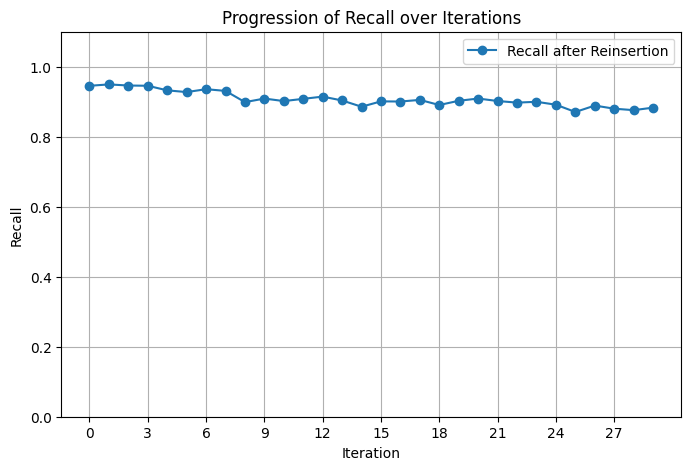

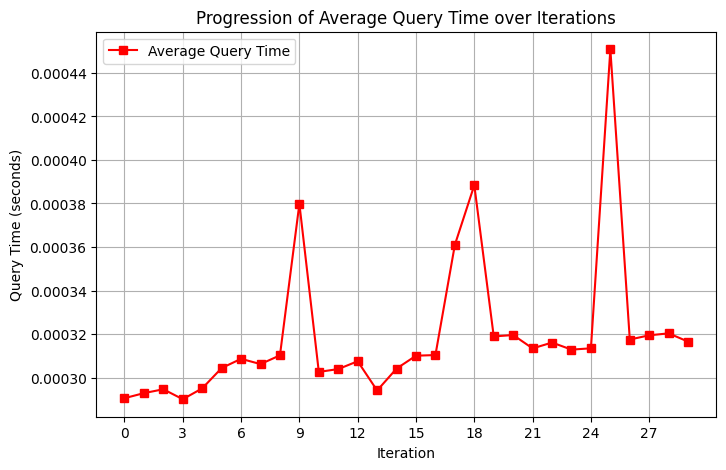

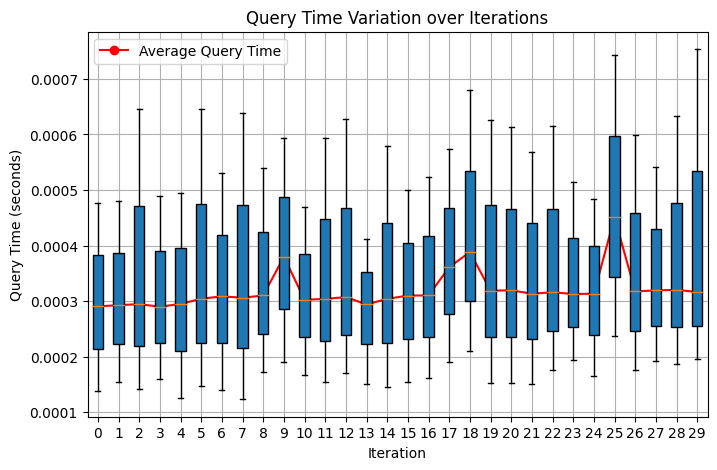

In [3]:
plot_recall_and_query_time_variation("hnsw_sift_same_size_index.json")
